<a href="https://colab.research.google.com/github/maheshkumar30/DataScience/blob/main/NN_Frameworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

# **LOAD MNIST DATASET**

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Dataset Shapes
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


# **DATA VISUALIZATION**

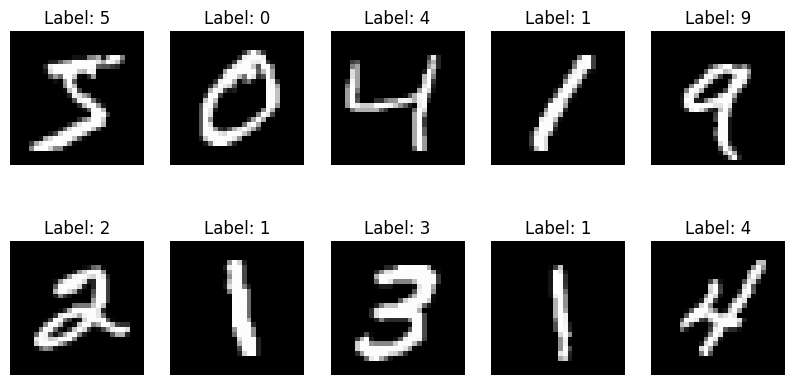

In [5]:

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

# **DATA PREPROCESSING**


In [6]:
# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-Hot Encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("After One Hot Encoding:")
print(y_train_cat[0])

After One Hot Encoding:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


# **BUILD NEURAL NETWORK MODEL**

In [7]:
model = Sequential()

# Input Layer + Flatten
model.add(Flatten(input_shape=(28,28)))

# Hidden Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **COMPILE MODEL**

In [8]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# **TRAIN MODEL**

In [9]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7125 - loss: 0.9445 - val_accuracy: 0.9030 - val_loss: 0.3661
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8669 - loss: 0.4496 - val_accuracy: 0.9208 - val_loss: 0.2776
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8931 - loss: 0.3632 - val_accuracy: 0.9339 - val_loss: 0.2324
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9084 - loss: 0.3104 - val_accuracy: 0.9403 - val_loss: 0.2036
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9181 - loss: 0.2794 - val_accuracy: 0.9462 - val_loss: 0.1854
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9252 - loss: 0.2544 - val_accuracy: 0.9502 - val_loss: 0.1700
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9315 - loss: 0.2338 - val_accuracy: 0.9533 - val_loss: 0.1575
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9366 - loss: 0.2185 - 

# **EVALUATE MODEL**

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9606 - loss: 0.1318

Test Loss: 0.13176782429218292
Test Accuracy: 0.9606000185012817


# **PLOT TRAINING ACCURACY**

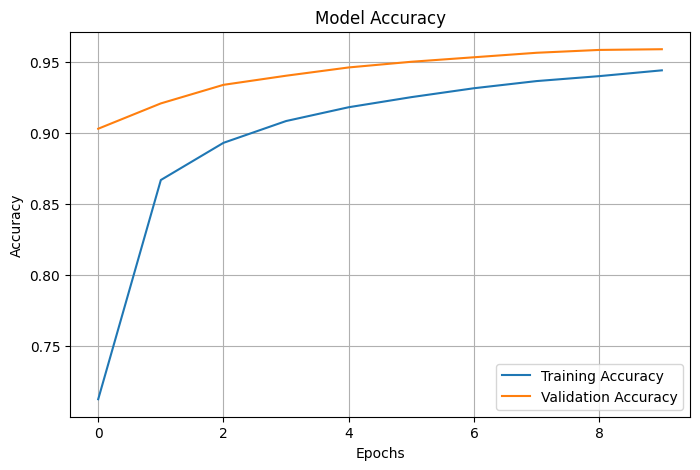

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)
plt.show()

# **PLOT TRAINING LOSS**


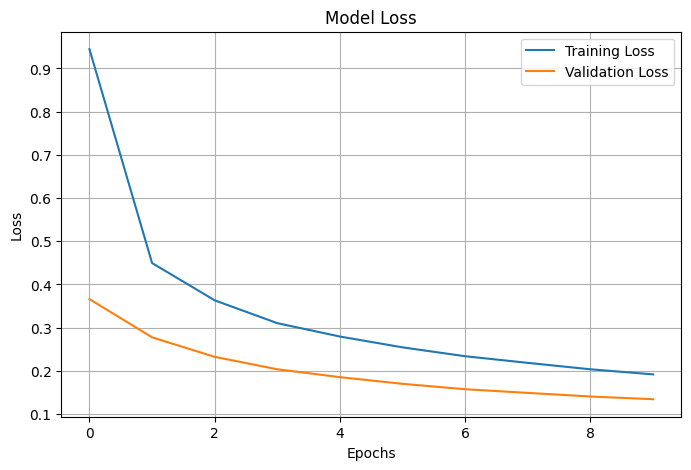

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)
plt.show()

# **MAKE PREDICTIONS**

In [13]:
predictions = model.predict(X_test)

# Convert Probabilities to Labels
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# **DISPLAY SAMPLE PREDICTIONS**

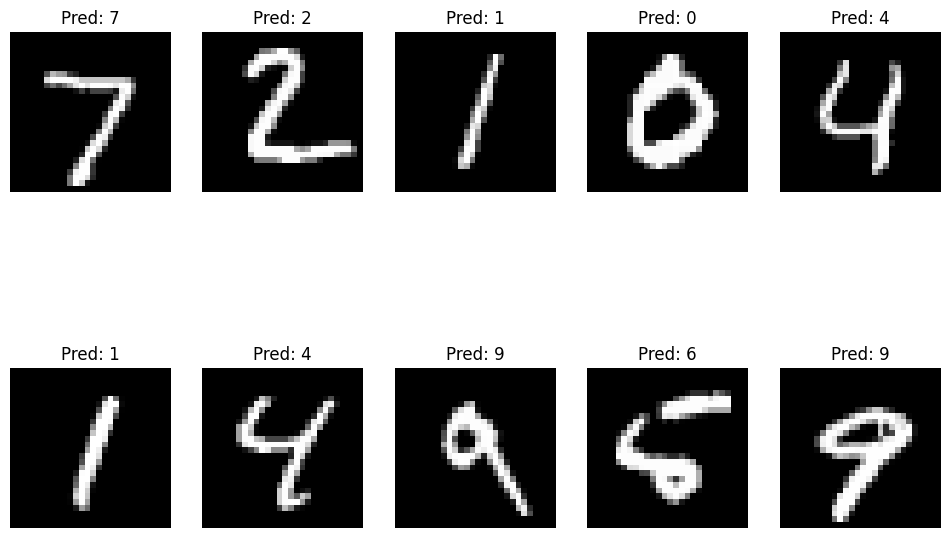

In [14]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(f"Pred: {predicted_labels[i]}")

    plt.axis('off')

plt.show()

# **CLASSIFICATION REPORT**

In [15]:
print("\nClassification Report:\n")

print(classification_report(y_test, predicted_labels))


Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.96      0.96      0.96      1032
           3       0.96      0.95      0.96      1010
           4       0.96      0.96      0.96       982
           5       0.96      0.95      0.95       892
           6       0.96      0.97      0.96       958
           7       0.96      0.95      0.96      1028
           8       0.95      0.94      0.95       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



# **CONFUSION MATRIX**

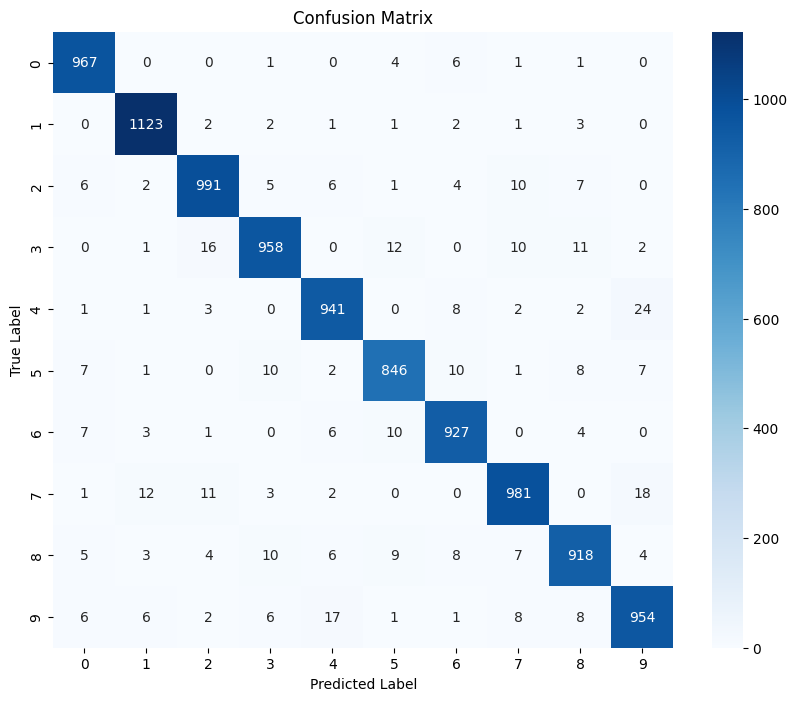

In [16]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# **SINGLE IMAGE PREDICTION**

In [17]:

sample_image = X_test[0]

sample_image = sample_image.reshape(1,28,28)

prediction = model.predict(sample_image)

digit = np.argmax(prediction)

print("\nPredicted Digit:", digit)
print("Actual Digit:", y_test[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Predicted Digit: 7
Actual Digit: 7


# SAVE MODEL

In [18]:
model.save("mnist_digit_classifier.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!


# **FINAL ANALYSIS**


In [19]:

print("\nPROJECT ANALYSIS")

print("1. The neural network successfully classifies handwritten digits.")
print("2. ReLU activation improves learning performance.")
print("3. Softmax activation provides probability outputs.")
print("4. Dropout reduces overfitting.")
print("5. Model achieves high classification accuracy on MNIST dataset.")


PROJECT ANALYSIS
1. The neural network successfully classifies handwritten digits.
2. ReLU activation improves learning performance.
3. Softmax activation provides probability outputs.
4. Dropout reduces overfitting.
5. Model achieves high classification accuracy on MNIST dataset.
